In [1]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
from treeple.experimental import StreamDecisionForest
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import xgboost as xgb

In [2]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 1000000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [3]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df


In [ ]:
T = 128
gamma = 0.5
t_prime = 6
PREGRETS = []
for rep in range(1):
    PREGRET = []
    for DELTA_t in [i*1 for i in np.arange(100)]:
        actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                        session_duration = 500000,
                                                        tdim=50, 
                                                        n_sessions=1,seed  = 515+rep)
        state_posencode_oh = position_encoder(states[:,0], type="onehot")
        new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
        print('training timestamps', T)
        state_posencode_oh = position_encoder(states[:,0], type="onehot")
        new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
        X_train = new_state_oh[:T,:]
        Y_train = irewards[:T]
        rf = xgb.XGBRegressor(
                objective="reg:squarederror",
                tree_method="exact",     # or "exact" (slower, RAM heavy)
                n_jobs = -1,
                learning_rate=0.05, max_depth=10,
                subsample=1, colsample_bytree=0.8,
                n_estimators=2000, eval_metric="rmse"
            )
        rf.fit(X_train, Y_train)
        print(T,'train done')
        current_state = states[T,0]

        ## 'online training'
        for delta_t in range(DELTA_t):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)

            n_paths = df_all_paths.shape[0]
            irewards_pred = np.zeros((n_paths,  t_prime+1))

            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                irewards_pred[:,i] = rf.predict(features)

            # # Convert to DataFrame for inspection
            reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
            df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
            # Extract rewards from second column onward (t=1 to t=T)
            rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
            discounts = gamma ** np.arange(1, t_prime+1)

            # Compute discounted total reward per path
            discounted_returns = rewards_matrix * discounts  
            total_discounted = discounted_returns.sum(axis=1)
            # print(total_discounted)
            bext_idx = np.argmax(total_discounted)
            next_state = int(df_all_paths.iloc[bext_idx,1])
            next_state_oh = position_encoder(np.array([next_state]), type="onehot")
            next_time = T+1+delta_t
            next_time_emb = time_embedding_np(next_time, tdim=50)
            next_features = np.hstack([next_state_oh,next_time_emb.reshape(1,-1)])
            next_reward = reward_simulate(next_state, next_time-1,rewards_in_period)
            # X_train = np.vstack([X_train,next_features])
            # Y_train = np.vstack([Y_train.reshape(-1,1),np.array([next_reward]).reshape(-1,1)])
            
            rf = xgb.XGBRegressor(
                objective="reg:squarederror",
                tree_method="exact",     # or "exact" (slower, RAM heavy)
                n_jobs = -1,
                learning_rate=0.05, max_depth=10,
                subsample=1, colsample_bytree=0.8,
                n_estimators=2000, eval_metric="rmse"
            )
            rf.fit(X_train, Y_train)
        # inference
        T_p = DELTA_t+T
        print(T_p,'train done')
        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
        for delta_t_p in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T_p+delta_t_p,t_prime=t_prime)
            # print(f"Total paths: {len(df_all_paths)}")
            # states_seq = df_all_paths[state_cols].to_numpy() 

            n_paths = df_all_paths.shape[0]
            irewards_pred = np.zeros((n_paths,  t_prime+1))

            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T_p+1+delta_t_p+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                irewards_pred[:,i] = rf.predict(features)

            # # Convert to DataFrame for inspection
            reward_cols = [f"t={T_p+delta_t_p+t}" for t in range(t_prime+1)]
            df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
            # Extract rewards from second column onward (t=1 to t=T)
            rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
            discounts = gamma ** np.arange(1, t_prime+1)

            # Compute discounted total reward per path
            discounted_returns = rewards_matrix * discounts  
            total_discounted = discounted_returns.sum(axis=1)
            # print(total_discounted)
            bext_idx = np.argmax(total_discounted)
            next_state = int(df_all_paths.iloc[bext_idx,1])
            # print(df_all_paths.iloc[bext_idx,:])
            future_states.append(next_state)
            current_state = next_state
            # print(T+delta_t+1,current_state)
        print(T_p,future_states,len(future_states))
        irewards_test = [reward_simulate(future_states[i],T_p+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards_test,100,0.5)
        path, ireward_opt = path_opt(future_states[0], T_p, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        PREGRET.append(pregret)
        # plt.plot(np.arange(T_p+1,T_p+101),future_states[1:])
        # plt.plot(np.arange(T_p,T_p+101),path)
        # plt.show()
    PREGRETS.append(PREGRET)

In [83]:
def train_model(X, Y, rf=None):
    """Train or continue training the XGBRegressor."""
    if rf is None:
        rf = xgb.XGBRegressor(
            objective="reg:squarederror",
            tree_method="exact",
            n_jobs=-1,
            learning_rate=0.05, max_depth=10,
            subsample=1, colsample_bytree=0.8,
            n_estimators=1000, eval_metric="rmse"
        )
        rf.fit(X, Y)
    else:
        rf.fit(X, Y)  # incremental update
    return rf

def predict_paths(rf, df_paths, t_start, t_prime):
    n_paths = df_paths.shape[0]
    preds = np.zeros((n_paths, t_prime+1))
    for i in range(t_prime+1):
        cand_pe = position_encoder(df_paths.iloc[:,i], type="onehot")
        curr_time = t_start + 1 + i
        time_emb = time_embedding_np(np.ones(cand_pe.shape[0]) * curr_time, tdim=50)
        features = np.hstack([cand_pe, time_emb])
        preds[:, i] = rf.predict(features)
    return preds

def choose_next_state(rf, current_state, t_now, t_prime, gamma):
    """Pick best next state based on discounted rewards."""
    df_paths = enumerate_paths(x0=current_state, t_inital=t_now, t_prime=t_prime)
    preds = predict_paths(rf, df_paths, t_now, t_prime)

    rewards_matrix = preds[:, 1:]   # ignore first col (current)
    discounts = gamma ** np.arange(1, t_prime+1)
    total_disc = (rewards_matrix * discounts).sum(axis=1)

    best_idx = np.argmax(total_disc)
    return int(df_paths.iloc[best_idx, 1]), df_paths, preds

def run_inference(rf, start_state, T_p, t_prime, gamma, rewards_in_period):
    """Generate future trajectory and compute regret."""
    current_state = start_state
    future_states = [current_state]

    for delta_t in range(100):
        next_state, df_paths, preds = choose_next_state(rf, current_state, T_p + delta_t, t_prime, gamma)
        future_states.append(next_state)
        current_state = next_state

    # compute rewards
    irewards_test = [reward_simulate(future_states[i], T_p+i, rewards_in_period) 
                     for i in range(1, len(future_states))]
    preward = compute_normalized_future_rewards(irewards_test, 100, gamma)

    # optimal path benchmark
    path, ireward_opt = path_opt(future_states[0], T_p, 100)
    preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:], 100, gamma)

    pregret = (np.sum(preward_opt_test).item() - np.sum(preward).item()) / 100

    # plotting
    # plt.plot(np.arange(T_p+1, T_p+101), future_states[1:], label="learned")
    # plt.plot(np.arange(T_p,   T_p+101), path, label="optimal")
    # plt.legend()
    # plt.show()

    return pregret


T = 200
gamma = 0.5
t_prime = 6
PREGRETS = []

for rep in range(10):
    # one simulation per rep
    actions, states, irewards, times = simulate_data_raw(
        rewards_in_period=rewards_in_period,
        session_duration=2000,
        tdim=50, n_sessions=1, seed=515+rep
    )

    # initial dataset
    X_train = np.hstack([position_encoder(states[:T,0], type="onehot"), states[:T,1:]])
    Y_train = irewards[:T]
    rf = train_model(X_train, Y_train)

    PREGRET = []
    # --- online training ---
    current_state = states[T,0]
    for delta_t in range(200):
        next_state, df_paths, preds = choose_next_state(rf, current_state, T+delta_t, t_prime, gamma)
        next_time = T+1+delta_t
        next_features = np.hstack([
            position_encoder(np.array([next_state]), type="onehot"),
            time_embedding_np(next_time, tdim=50).reshape(1,-1)
        ])
        next_reward = reward_simulate(next_state, next_time-1, rewards_in_period)

        X_train = np.vstack([X_train, next_features])
        Y_train = np.vstack([Y_train.reshape(-1,1), [[next_reward]]])
        # X_train = np.hstack([position_encoder(states[:T+delta_t,0], type="onehot"), states[:T+delta_t,1:]])
        # Y_train = irewards[:T+delta_t]
        rf = train_model(X_train, Y_train, rf)
        current_state = next_state  # move forward

    
        T_p = delta_t + T
        start_state = current_state
        pregret_val = run_inference(rf, start_state, T_p, t_prime, gamma, rewards_in_period)
        print(f"rep {rep}, T_train {T_p}, pregret={pregret_val:.4f}")
        PREGRET.append(pregret_val)

    PREGRETS.append(PREGRET)


rep 0, T_train 200, pregret=0.7298
rep 0, T_train 201, pregret=0.8306
rep 0, T_train 202, pregret=0.3922
rep 0, T_train 203, pregret=0.3915
rep 0, T_train 204, pregret=0.4715
rep 0, T_train 205, pregret=0.4680
rep 0, T_train 206, pregret=0.3804
rep 0, T_train 207, pregret=0.3693
rep 0, T_train 208, pregret=0.2314
rep 0, T_train 209, pregret=0.2807
rep 0, T_train 210, pregret=0.7501
rep 0, T_train 211, pregret=0.8635
rep 0, T_train 212, pregret=0.9542
rep 0, T_train 213, pregret=1.1459
rep 0, T_train 214, pregret=1.1487
rep 0, T_train 215, pregret=0.9501
rep 0, T_train 216, pregret=0.7126
rep 0, T_train 217, pregret=0.9500
rep 0, T_train 218, pregret=0.9500
rep 0, T_train 219, pregret=0.9500
rep 0, T_train 220, pregret=0.0047
rep 0, T_train 221, pregret=0.0000
rep 0, T_train 222, pregret=0.0000
rep 0, T_train 223, pregret=0.0000
rep 0, T_train 224, pregret=0.0000
rep 0, T_train 225, pregret=0.0000
rep 0, T_train 226, pregret=0.0000
rep 0, T_train 227, pregret=0.0000
rep 0, T_train 228, 

In [89]:
def train_model(X, Y, rf=None):
    """Train or continue training the XGBRegressor."""
    if rf is None:
        rf = xgb.XGBRegressor(
            objective="reg:squarederror",
            tree_method="exact",
            n_jobs=-1,
            learning_rate=0.05, max_depth=10,
            subsample=1, colsample_bytree=0.8,
            n_estimators=1000, eval_metric="rmse"
        )
        rf.fit(X, Y)
    else:
        rf.fit(X, Y)  # incremental update
    return rf

def predict_paths(rf, df_paths, t_start, t_prime):
    n_paths = df_paths.shape[0]
    preds = np.zeros((n_paths, t_prime+1))
    for i in range(t_prime+1):
        cand_pe = position_encoder(df_paths.iloc[:,i], type="onehot")
        curr_time = t_start + 1 + i
        time_emb = time_embedding_np(np.ones(cand_pe.shape[0]) * curr_time, tdim=50)
        features = np.hstack([cand_pe, time_emb])
        preds[:, i] = rf.predict(features)
    return preds

def choose_next_state(rf, current_state, t_now, t_prime, gamma):
    """Pick best next state based on discounted rewards."""
    df_paths = enumerate_paths(x0=current_state, t_inital=t_now, t_prime=t_prime)
    preds = predict_paths(rf, df_paths, t_now, t_prime)

    rewards_matrix = preds[:, 1:]   # ignore first col (current)
    discounts = gamma ** np.arange(1, t_prime+1)
    total_disc = (rewards_matrix * discounts).sum(axis=1)

    best_idx = np.argmax(total_disc)
    return int(df_paths.iloc[best_idx, 1]), df_paths, preds

def run_inference(rf, start_state, T_p, t_prime, gamma, rewards_in_period):
    """Generate future trajectory and compute regret."""
    current_state = start_state
    future_states = [current_state]

    for delta_t in range(100):
        next_state, df_paths, preds = choose_next_state(rf, current_state, T_p + delta_t, t_prime, gamma)
        future_states.append(next_state)
        current_state = next_state

    # compute rewards
    irewards_test = [reward_simulate(future_states[i], T_p+i, rewards_in_period) 
                     for i in range(1, len(future_states))]
    preward = compute_normalized_future_rewards(irewards_test, 100, gamma)

    # optimal path benchmark
    path, ireward_opt = path_opt(future_states[0], T_p, 100)
    preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:], 100, gamma)

    pregret = (np.sum(preward_opt_test).item() - np.sum(preward).item()) / 100

    # plotting
    # plt.plot(np.arange(T_p+1, T_p+101), future_states[1:], label="learned")
    # plt.plot(np.arange(T_p,   T_p+101), path, label="optimal")
    # plt.legend()
    # plt.show()

    return pregret


T = 200
gamma = 0.5
t_prime = 6
PREGRETS_random = []

for rep in range(10):
    # one simulation per rep
    actions, states, irewards, times = simulate_data_raw(
        rewards_in_period=rewards_in_period,
        session_duration=2000,
        tdim=50, n_sessions=1, seed=515+rep
    )

    # initial dataset
    X_train = np.hstack([position_encoder(states[:T,0], type="onehot"), states[:T,1:]])
    Y_train = irewards[:T]
    rf = train_model(X_train, Y_train)

    PREGRET = []
    # --- online training ---
    current_state = states[T,0]
    for delta_t in range(200):
        next_state, df_paths, preds = choose_next_state(rf, current_state, T+delta_t, t_prime, gamma)
        next_time = T+1+delta_t
        next_features = np.hstack([
            position_encoder(np.array([next_state]), type="onehot"),
            time_embedding_np(next_time, tdim=50).reshape(1,-1)
        ])
        next_reward = reward_simulate(next_state, next_time-1, rewards_in_period)

        # X_train = np.vstack([X_train, next_features])
        # Y_train = np.vstack([Y_train.reshape(-1,1), [[next_reward]]])
        X_train = np.hstack([position_encoder(states[:T+delta_t,0], type="onehot"), states[:T+delta_t,1:]])
        Y_train = irewards[:T+delta_t]
        rf = train_model(X_train, Y_train, rf)

        current_state = next_state  # move forward

    
        T_p = delta_t + T
        start_state = current_state
        pregret_val = run_inference(rf, start_state, T_p, t_prime, gamma, rewards_in_period)
        print(f"rep {rep}, T_train {T_p}, pregret={pregret_val:.4f}")
        PREGRET.append(pregret_val)

    PREGRETS_random.append(PREGRET)


rep 0, T_train 200, pregret=0.7298
rep 0, T_train 201, pregret=0.6903
rep 0, T_train 202, pregret=0.5714
rep 0, T_train 203, pregret=0.9483
rep 0, T_train 204, pregret=0.7091
rep 0, T_train 205, pregret=0.7056
rep 0, T_train 206, pregret=0.4750
rep 0, T_train 207, pregret=0.4705
rep 0, T_train 208, pregret=0.4716
rep 0, T_train 209, pregret=0.2345
rep 0, T_train 210, pregret=0.4925
rep 0, T_train 211, pregret=0.3560
rep 0, T_train 212, pregret=0.3440
rep 0, T_train 213, pregret=0.4363
rep 0, T_train 214, pregret=0.4340
rep 0, T_train 215, pregret=0.6705
rep 0, T_train 216, pregret=0.3352
rep 0, T_train 217, pregret=0.5294
rep 0, T_train 218, pregret=0.5292
rep 0, T_train 219, pregret=0.5292
rep 0, T_train 220, pregret=0.5291
rep 0, T_train 221, pregret=0.5291
rep 0, T_train 222, pregret=0.7658
rep 0, T_train 223, pregret=0.3347
rep 0, T_train 224, pregret=0.6659
rep 0, T_train 225, pregret=0.6625
rep 0, T_train 226, pregret=0.4319
rep 0, T_train 227, pregret=0.5637
rep 0, T_train 228, 

In [61]:
len(PREGRETS)

5

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_90008/2492321606.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('PuRd')


Text(0.5, 1.0, 'Prospective Regret Across Lookahead Steps - Online ProForg')

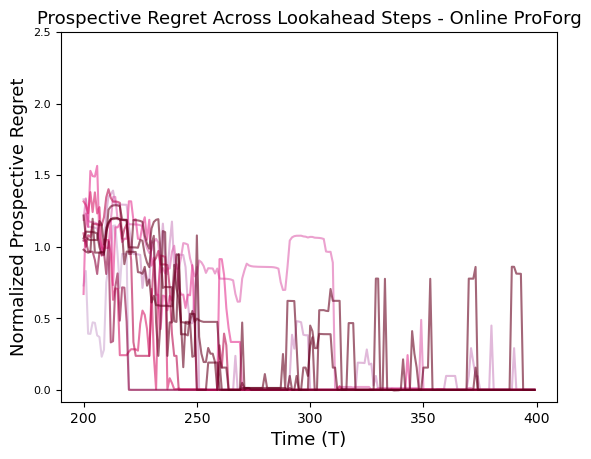

In [91]:
cmap = cm.get_cmap('PuRd')
fontsize = 13
cmap_color = [cmap(0.3 + i*0.1) for i in range(10)]
for i in range(10):
    plt.plot(np.arange(200,400),PREGRETS[i],alpha = 0.6,color = cmap_color[i])
plt.xticks([200,250,300,350,400])
plt.yticks([0,0.5,1,1.5,2,2.5],fontsize = fontsize-5)
plt.xlabel("Time (T)",fontsize = fontsize)
plt.ylabel("Normalized Prospective Regret", fontsize = fontsize)
# plt.xscale('log')
plt.title('Prospective Regret Across Lookahead Steps - Online ProForg',fontsize = fontsize)

In [90]:
PREGRETS_arr = np.vstack(PREGRETS)
PREGRETS_random_arr = np.vstack(PREGRETS_random)
np.savez(
    f"../results/OnlinePAFM/GBT_oh_w_time200_400_lookahead{t_prime}_10reps.npz",
    pregrets_online = PREGRETS_arr,
    pregrets_offline = PREGRETS_random_arr,
    )
PREGRETS_arr.shape

(10, 200)

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_90008/222274679.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues')


Text(0.5, 1.0, 'Prospective Regret Across Lookahead Steps - "Random-Walk" ProForg')

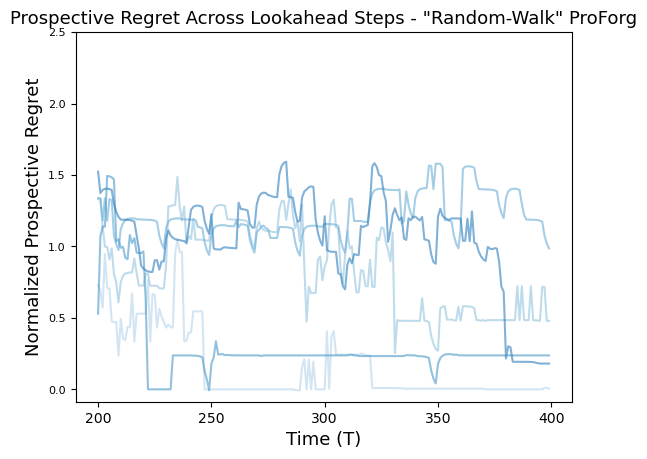

In [93]:
cmap = cm.get_cmap('Blues')
fontsize = 13
cmap_color = [cmap(0.3 + i*0.1) for i in range(10)]
for i in range(5):
    plt.plot(np.arange(200,400),PREGRETS_random[i],alpha = 0.6,color = cmap_color[i])
plt.xticks([200,250,300,350,400])
plt.yticks([0,0.5,1,1.5,2,2.5],fontsize = fontsize-5)
plt.xlabel("Time (T)",fontsize = fontsize)
plt.ylabel("Normalized Prospective Regret", fontsize = fontsize)
# plt.xscale('log')
plt.title('Prospective Regret Across Lookahead Steps - "Random-Walk" ProForg',fontsize = fontsize)